In [13]:
## Shaft Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
 
class ShaftAnalysis:
    def __init__(self, material_name="4140 Steel", L_Total=3.1, d_mm=70, bearing_locs=(0.2, 2.9)):
        # ================= GEOMETRY =================
        self.L_Total = L_Total
        self.d_mm = d_mm
        self.d = d_mm / 1000.0
        self.Loc_Bearing_L = bearing_locs[0]
        self.Loc_Bearing_R = bearing_locs[1]
        
        # ================= LOADS =================
        self.Mass_Table = 50.0       
        self.Mass_Payload_Dynamic = 60.0 
        self.Mass_Payload_Static_lb = 250.0  
        self.Mass_Payload_Static = self.Mass_Payload_Static_lb * 0.453592 
        
        # Offsets
        self.Offset_Y_Dynamic = 0.75  # Used for Offset Case
        self.Mass_Offset_Table = 0.05 
        
        # Motor Specs
        self.Torque_Rated = 250   
        self.Torque_Stall = 750   
        
        # Safety Factors
        self.SF_Req_Static = 4.0
        self.SF_Req_Offset = 1.5
        self.SF_Req_Dynamic = 2.0
        self.SF_Req_Stall = 1.5
        
        # Stress Concentrations
        self.Kt_Bending = 2.14
        self.Kt_Torsion = 3.00

        # ================= MATERIAL LIBRARY =================
        self.materials = {
            "4140 Steel": {'Yield': 800e6, 'E': 205e9, 'G': 80e9},
            "1018 Steel": {'Yield': 370e6, 'E': 205e9, 'G': 80e9},
            "304 SS":     {'Yield': 215e6, 'E': 193e9, 'G': 77e9},
        }
        self.set_material(material_name)

    def set_material(self, name):
        if name not in self.materials: name = "4140 Steel"
        mat = self.materials[name]
        self.Material_Name = name
        self.Yield_Strength = mat['Yield']
        self.E_Modulus = mat['E']
        self.G_Modulus = mat['G']
        
        # Section Props
        self.I = (np.pi * self.d**4) / 64
        self.J = (np.pi * self.d**4) / 32
        self.c = self.d / 2

    # ================= CALCULATION ENGINE =================
    def _calc_single_case(self, name, Force, Loc_Load, T_Input, T_Load, Holding_Element):
        """
        T_Input: Motor Torque (Left side)
        T_Load:  Payload Torque (Middle)
        Holding_Element: 'Motor' or 'Brake' (determines where stress flows)
        """
        Span = self.Loc_Bearing_R - self.Loc_Bearing_L
        Dist_a = Loc_Load - self.Loc_Bearing_L
        
        # 1. BEAM REACTION FORCES
        if self.Loc_Bearing_L <= Loc_Load <= self.Loc_Bearing_R:
            R_Right = (Force * Dist_a) / Span
            R_Left = Force - R_Right
            Max_Moment = R_Left * Dist_a
        else:
            # Overhang Logic
            Dist_Overhang = abs(Loc_Load - self.Loc_Bearing_L) if Loc_Load < self.Loc_Bearing_L else abs(Loc_Load - self.Loc_Bearing_R)
            Max_Moment = Force * Dist_Overhang
            R_Left = Force * 0.5; R_Right = Force * 0.5 # Simplified

        # 2. TORQUE STRESS LOGIC
        # If Brake holds Load: Shaft segment between Load and Brake is stressed.
        # If Motor holds Load: Shaft segment between Motor and Load is stressed.
        
        if Holding_Element == 'Brake':
            # Stress is max(Load_Trq, Brake_Holding_Trq)
            # Brake is at Right end, Load is in middle.
            T_Stress = T_Load 
            T_Brake = T_Load # Brake matches load to hold equilibrium
            T_Motor_Actual = 0
        elif Holding_Element == 'Motor':
            T_Stress = max(T_Input, T_Load)
            T_Motor_Actual = T_Input
            T_Brake = 0
        else: # None (Free spinning or 0 torque)
            T_Stress = 0
            T_Motor_Actual = 0
            T_Brake = 0

        # 3. STRESS & SF
        Sigma_Bend = (Max_Moment * self.c) / self.I * self.Kt_Bending
        Tau_Twist = (T_Stress * self.c) / self.J * self.Kt_Torsion
        VonMises = np.sqrt(Sigma_Bend**2 + 3 * Tau_Twist**2)
        SF = self.Yield_Strength / VonMises if VonMises > 0 else 99.0

        return {
            'name': name, 'Force': Force, 'Loc_Load': Loc_Load,
            'T_Motor': T_Motor_Actual, 'T_Load': T_Load, 'T_Brake': T_Brake,
            'R_Left': R_Left, 'R_Right': R_Right,
            'Max_Moment': Max_Moment, 'VonMises': VonMises, 'SF': SF,
            'color': 'purple' if 'Static' in name else ('green' if 'Dynamic' in name else 'red')
        }

    def run_analysis(self):
        self.results = []
        g = 9.81
        
        # 1. Static (Dead Center) - NO TORQUE
        # User condition: X=0, Y=0. Dead center. STO active.
        F_Stat = (self.Mass_Table + self.Mass_Payload_Static) * g
        self.results.append(self._calc_single_case("Static (Dead Center)", F_Stat, self.L_Total/2, 
                                                   T_Input=0, T_Load=0, Holding_Element='None'))
        
        # 2. Static (Offset) - BRAKE HOLDING
        # User condition: Load has Y offset. Brake opposes it.
        # T_Stress exists between Load and Brake.
        T_Offset = (self.Mass_Payload_Static * self.Offset_Y_Dynamic) * g
        self.results.append(self._calc_single_case("Static (Offset Hold)", F_Stat, self.L_Total/2, 
                                                   T_Input=0, T_Load=T_Offset, Holding_Element='Brake'))

        # 3. Dynamic (Normal) - MOTOR DRIVING
        F_Dyn = (self.Mass_Table + self.Mass_Payload_Dynamic) * g
        T_Dyn_Load = (self.Mass_Table * self.Mass_Offset_Table * g)
        self.results.append(self._calc_single_case("Dynamic (Normal)", F_Dyn, self.L_Total/2, 
                                                   T_Input=self.Torque_Rated, T_Load=T_Dyn_Load, Holding_Element='Motor'))
        
        # 4. Stall (Crash) - MOTOR MAXED
        self.results.append(self._calc_single_case("Stall (Crash)", F_Dyn, self.L_Total/2, 
                                                   T_Input=self.Torque_Stall, T_Load=T_Dyn_Load, Holding_Element='Motor'))

    # ================= DEFLECTION (Double Integration) =================
    def plot_deflection(self, case_index=0):
        """Calculates deflection using Double Integration Method"""
        res = self.results[case_index]
        Force = res['Force']
        Loc_Load = res['Loc_Load']
        
        # 1. Setup X array
        x = np.linspace(0, self.L_Total, 1000)
        dx = x[1] - x[0]
        M = np.zeros_like(x)
        
        # 2. Generate Moment Diagram M(x)
        # Reaction forces for calculation
        Span = self.Loc_Bearing_R - self.Loc_Bearing_L
        if self.Loc_Bearing_L <= Loc_Load <= self.Loc_Bearing_R:
            R_R = (Force * (Loc_Load - self.Loc_Bearing_L)) / Span
            R_L = Force - R_R
            
            for i, xi in enumerate(x):
                if xi > self.Loc_Bearing_L: M[i] += R_L * (xi - self.Loc_Bearing_L)
                if xi > Loc_Load:           M[i] -= Force * (xi - Loc_Load)
                if xi > self.Loc_Bearing_R: M[i] += R_R * (xi - self.Loc_Bearing_R)
        
        # 3. Integrate: Curvature -> Slope -> Deflection
        EI = self.E_Modulus * self.I
        Curvature = M / EI
        Slope_Raw = np.cumsum(Curvature) * dx
        Deflection_Raw = np.cumsum(Slope_Raw) * dx
        
        # 4. Apply Boundary Conditions (y=0 at Bearings)
        idx_L = np.abs(x - self.Loc_Bearing_L).argmin()
        idx_R = np.abs(x - self.Loc_Bearing_R).argmin()
        
        y_L = Deflection_Raw[idx_L]
        y_R = Deflection_Raw[idx_R]
        x_L = x[idx_L]
        x_R = x[idx_R]
        
        # Solve constants C1 * x + C2
        C1 = -(y_R - y_L) / (x_R - x_L)
        C2 = -y_L - (C1 * x_L)
        
        y_final_m = Deflection_Raw + C1*x + C2
        y_final_mm = y_final_m * 1000
        
        # 5. Plot
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(x, y_final_mm, color=res['color'], lw=3)
        ax.fill_between(x, y_final_mm, color=res['color'], alpha=0.1)
        
        # Draw Bearings
        ax.plot(self.Loc_Bearing_L, 0, 'k^', ms=15, label='Bearing')
        ax.plot(self.Loc_Bearing_R, 0, 'k^', ms=15)
        ax.axhline(0, color='k', ls='--')
        
        # Max Sag Label
        max_sag = np.max(np.abs(y_final_mm))
        ax.set_title(f"Deflection Profile: {res['name']}\nMax Sag: {max_sag:.3f} mm", fontsize=14, weight='bold')
        ax.set_ylabel("Deflection (mm)")
        ax.set_xlabel("Shaft Position (m)")
        ax.invert_yaxis()
        ax.grid(True, alpha=0.5)
        plt.show()

    # ================= FBD PLOT =================
    def plot_fbds(self):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18))
        fig.suptitle(f"FBD: {self.Material_Name} (Ø{self.d_mm}mm)", fontsize=20, weight='bold')
        
        for ax, res in zip(axes, self.results):
            # Shaft
            ax.add_patch(patches.Rectangle((0, -0.1), self.L_Total, 0.2, fc='#ddd', ec='k'))
            
            # Bearings & Reactions
            for loc, reac in zip([self.Loc_Bearing_L, self.Loc_Bearing_R], [res['R_Left'], res['R_Right']]):
                ax.add_patch(patches.Polygon([[loc, -0.1], [loc-0.08, -0.25], [loc+0.08, -0.25]], fc='gray', ec='k'))
                ax.annotate(f"{reac:.0f} N", xy=(loc, -0.25), xytext=(loc, -0.5),
                            arrowprops=dict(facecolor='blue', shrink=0.05), ha='center', color='blue')

            # Motor (Input Torque)
            ax.add_patch(patches.Rectangle((-0.2, -0.15), 0.2, 0.3, fc='#66BB6A', ec='k'))
            ax.text(-0.1, 0, "MOTOR", ha='center', color='white', weight='bold')
            if res['T_Motor'] > 0:
                ax.text(-0.3, 0, f"Input:\n{res['T_Motor']:.0f}Nm", ha='right', va='center', color='green', weight='bold')
                
            # Brake (Holding Torque)
            ax.add_patch(patches.Rectangle((self.L_Total, -0.15), 0.2, 0.3, fc='#EF5350', ec='k'))
            ax.text(self.L_Total+0.1, 0, "BRAKE", ha='center', color='white', weight='bold')
            if res['T_Brake'] > 0:
                ax.text(self.L_Total+0.3, 0, f"Holding:\n{res['T_Brake']:.0f}Nm", ha='left', va='center', color='red', weight='bold')

            # Load
            ax.annotate(f"{res['name']}\n{res['Force']:.0f} N", xy=(res['Loc_Load'], 0.1), xytext=(res['Loc_Load'], 0.6),
                        arrowprops=dict(facecolor=res['color'], shrink=0.05), ha='center', weight='bold', 
                        bbox=dict(boxstyle="round", fc="white"))
            
            # Load Torque Indication
            if res['T_Load'] > 0:
                ax.text(res['Loc_Load'], 0.25, f"Trq: {res['T_Load']:.0f}Nm ↻", ha='center', color=res['color'], weight='bold')

            ax.set_xlim(-0.6, self.L_Total + 0.6); ax.set_ylim(-0.7, 0.9); ax.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def plot_table(self):
        fig, ax = plt.subplots(figsize=(14, 4)); ax.axis('off')
        cols = ['Condition', 'Force(N)', 'Input Trq', 'Load Trq', 'Hold Trq', 'Max Moment', 'Stress(MPa)', 'SF', 'Status']
        cell_text = []
        colors = []
        
        for r in self.results:

            if "Offset" in r['name']:
                req = self.SF_Req_Offset
            elif "Static" in r['name']:
                req = self.SF_Req_Static
            elif "Stall" in r['name']:
                req = self.SF_Req_Stall
            else:
                req = self.SF_Req_Dynamic

            status = "✓ PASS" if r['SF'] >= req else "✗ FAIL"
            c = "#C6EFCE" if "PASS" in status else "#FFC7CE"
            
            cell_text.append([r['name'], f"{r['Force']:.0f}", f"{r['T_Motor']:.0f}", f"{r['T_Load']:.0f}", f"{r['T_Brake']:.0f}",
                              f"{r['Max_Moment']:.1f}", f"{r['VonMises']/1e6:.1f}", f"{r['SF']:.2f}", status])
            colors.append(['white']*(len(cols)-1) + [c])
            
        table = ax.table(cellText=cell_text, colLabels=cols, cellColours=colors, loc='center', cellLoc='center')
        table.scale(1, 2); table.auto_set_font_size(False); table.set_fontsize(10)
        table.get_celld()[(0,0)].set_facecolor('#4472C4')
        plt.show()

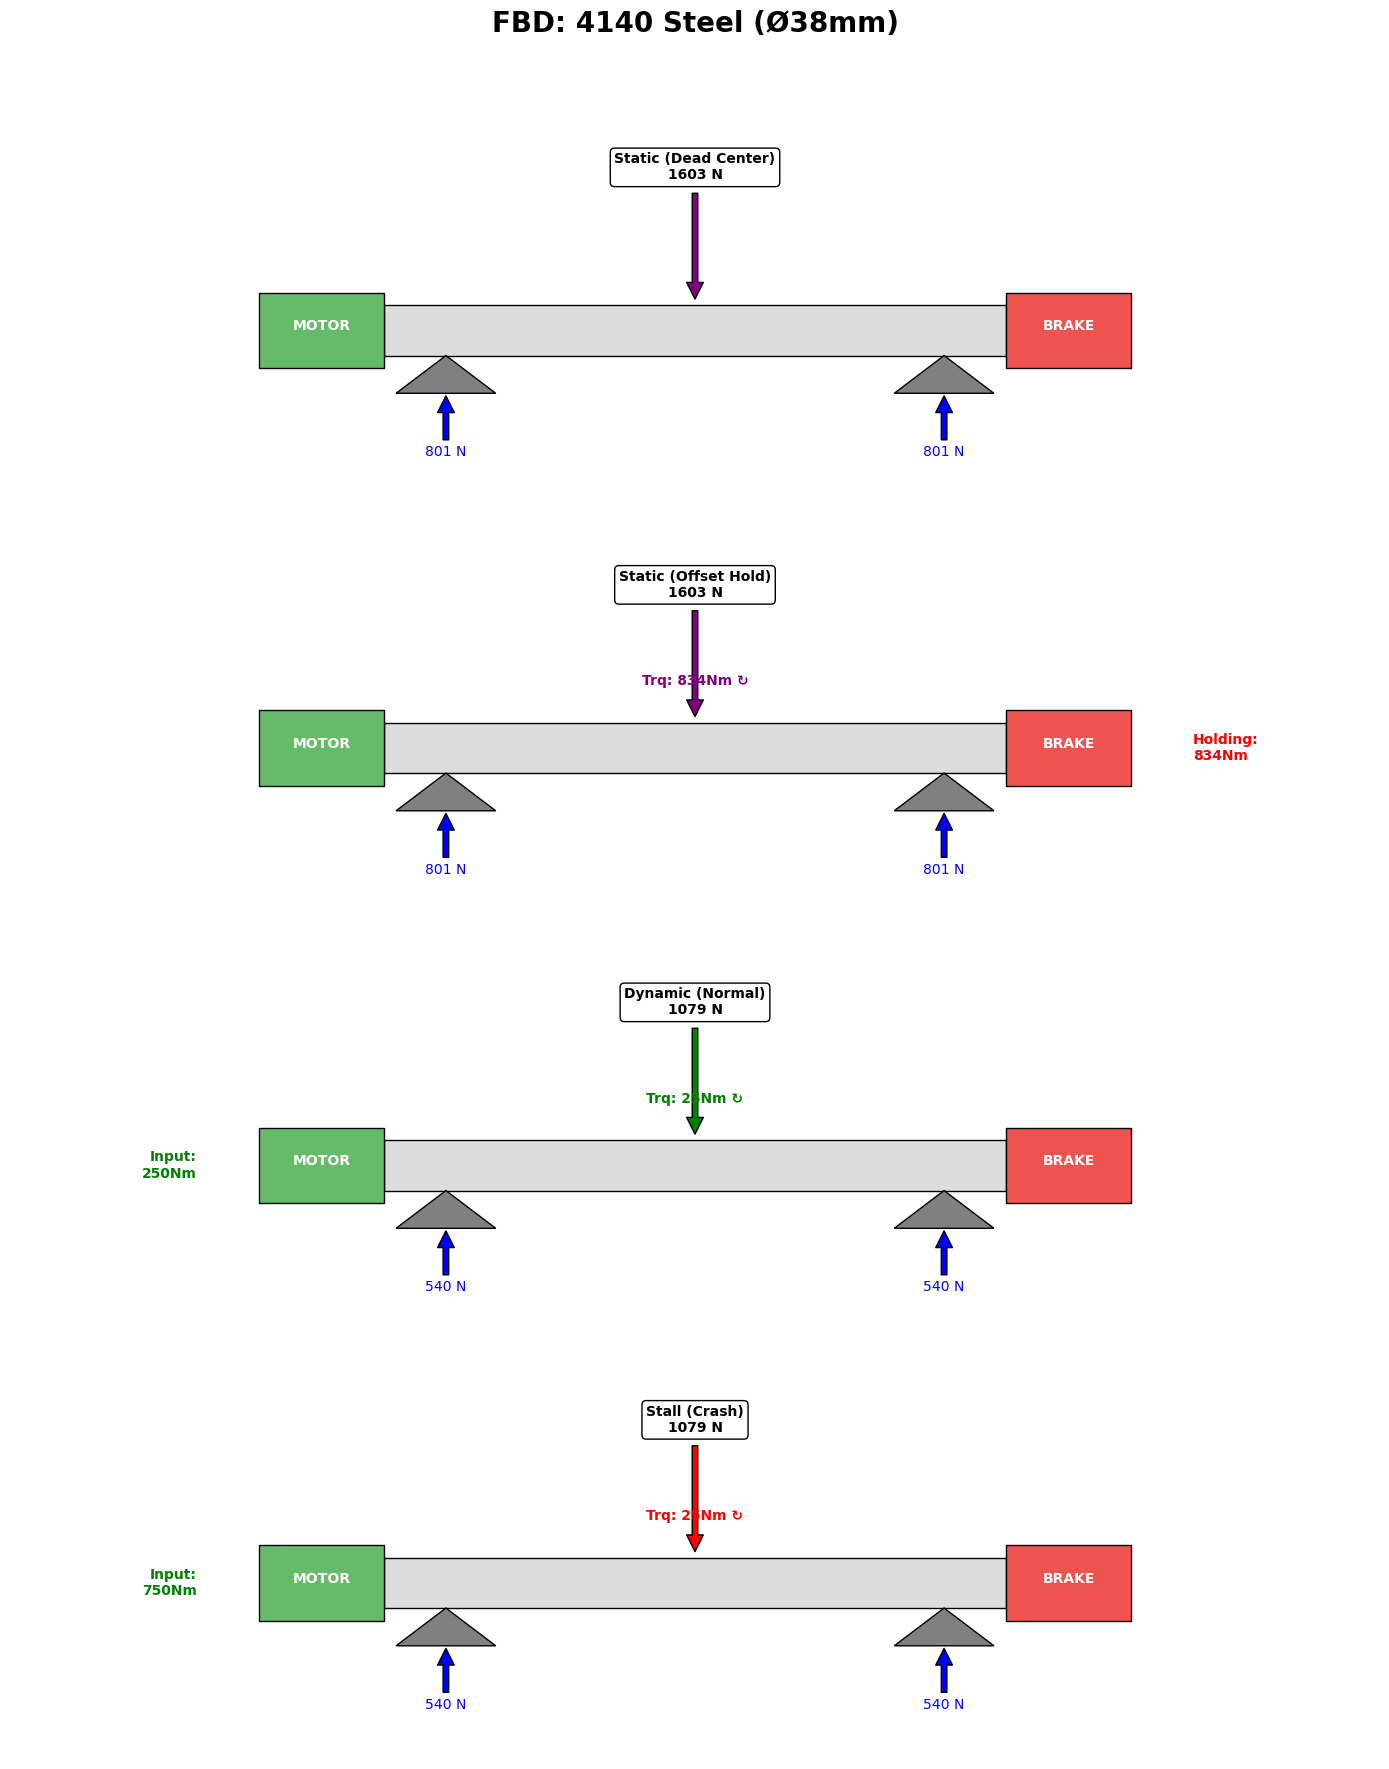

In [13]:
shaft = ShaftAnalysis(
    material_name="4140 Steel",
    L_Total=1,              # Total Shaft Length (m)
    d_mm=38,                  # Shaft Diameter (mm)
    bearing_locs=(0.1, 0.9)   # (Left Bearing x, Right Bearing x)
)

shaft.run_analysis()
shaft.plot_fbds()

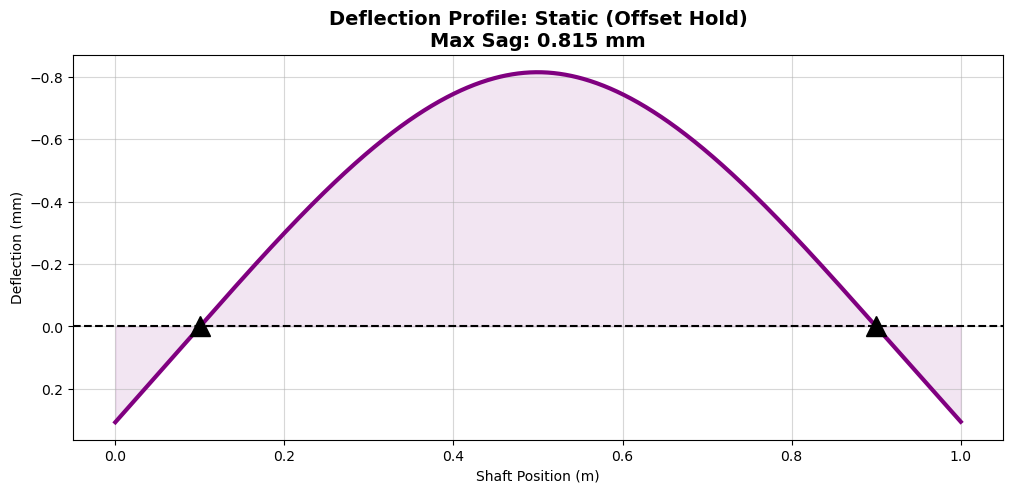

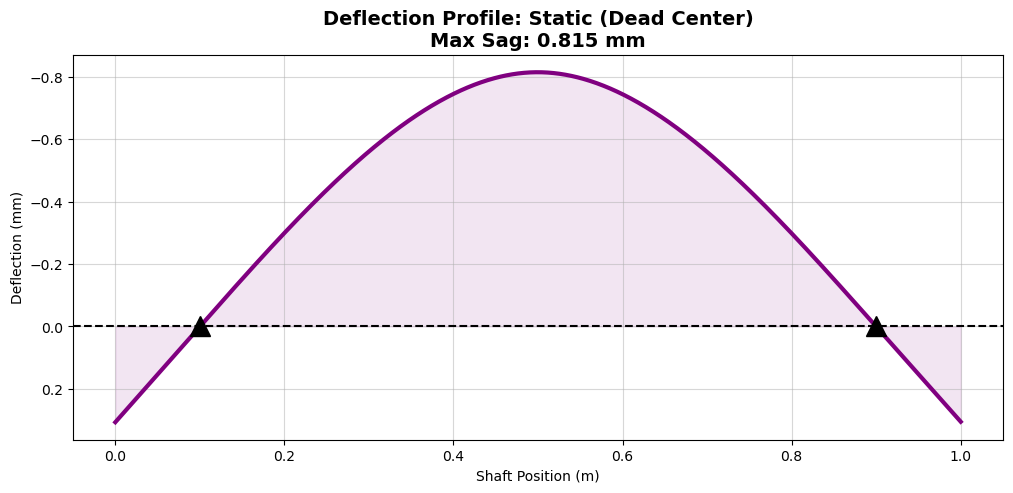

In [14]:
# Check Deflection for the "Static (Offset Hold)" case
shaft.plot_deflection(case_index=1)
shaft.plot_deflection(case_index=0)

## I searched from internet that this needs to be like 1mm, so yeah either change the bearing placement or idk do something


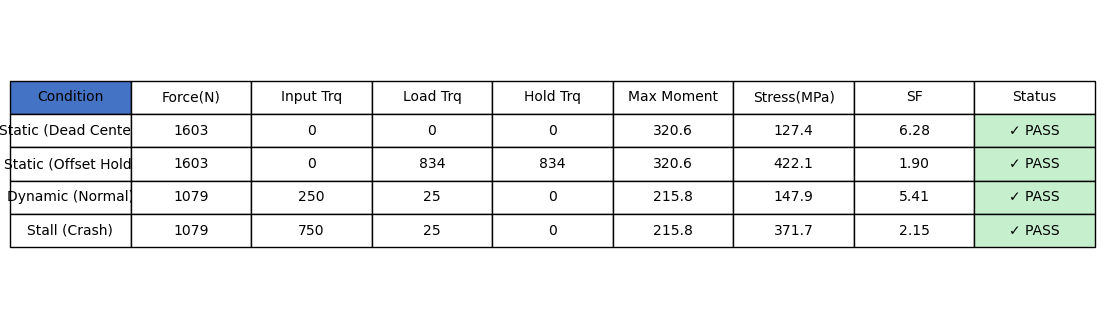

In [15]:
shaft.plot_table()


In [11]:
import matplotlib.pyplot as plt
import numpy as np

def add_material_tool(cls):
    """
    A Decorator that injects a 'compare_materials' method into the ShaftAnalysis class.
    """
    
    def compare_materials(self, case_name="Stall (Crash)"):
        # 1. Retrieve Stress from the existing analysis
        target_res = next((r for r in self.results if r['name'] == case_name), None)
        
        if target_res is None:
            print(f"Error: Case '{case_name}' not found. Available cases: {[r['name'] for r in self.results]}")
            return

        # Stress is geometry-dependent, not material-dependent. 
        # We can reuse the VonMises stress we already calculated.
        vm_stress = target_res['VonMises']
        print(f"Analyzing Case: '{case_name}'")
        print(f"Base Stress Level: {vm_stress/1e6:.1f} MPa")

        # 2. Define Material Database [Yield (Pa), Cost Index]
        # Cost Index 1.0 = Base (Cheap Steel)
        materials_db = {
            "1018 Mild Steel":      [370e6, 1.0], 
            "1045 Carbon Steel":    [530e6, 1.2], # Common TGP Shaft
            "4140 Steel (Pre-Hard)":[655e6, 2.1], # Your current choice
            "4340 Alloy Steel":     [750e6, 2.5],
            "304 Stainless":        [215e6, 3.5], # Expensive & Weak
            "17-4 PH SS (H900)":    [1170e6, 8.0],
            "Titanium Gr5":         [880e6, 15.0]
        }

        names, sfs, costs, colors = [], [], [], []

        # 3. Determine Required SF based on case name
        if "Offset" in case_name:
            req_sf = self.SF_Req_Offset
        elif "Static" in case_name:
            req_sf = self.SF_Req_Static
        elif "Stall" in case_name:
            req_sf = self.SF_Req_Stall
        else:
            req_sf = self.SF_Req_Dynamic

        # 4. Calculate Stats for each material
        for mat, props in materials_db.items():
            yld = props[0]
            cost = props[1]
            sf = yld / vm_stress if vm_stress > 0 else 99.0
            
            names.append(mat)
            sfs.append(sf)
            costs.append(cost)
            
            # Color Coding
            if sf < 1.0:
                colors.append('#ff4d4d') # Red (Fail)
            elif sf < req_sf:
                colors.append('#ffcc00') # Yellow (Marginal)
            else:
                colors.append('#66cc66') # Green (Pass)

        # 5. Plotting
        fig = plt.figure(figsize=(14, 6))
        gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

        # Plot A: Bar Chart (Strength)
        ax1 = fig.add_subplot(gs[0, 0])
        bars = ax1.barh(names, sfs, color=colors, edgecolor='k', alpha=0.8)
        ax1.axvline(req_sf, color='blue', ls='--', lw=2, label=f'Req SF {req_sf}')
        ax1.axvline(1.0, color='red', ls='-', lw=2, label='Yield')
        ax1.set_xlabel('Safety Factor')
        ax1.set_title(f'Safety Factor by Material ({case_name})')
        ax1.legend(loc='lower right')
        
        # Add values to bars
        for bar in bars:
            ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                     f'{bar.get_width():.2f}', va='center', fontweight='bold')

        # Plot B: Cost vs Performance
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.scatter(costs, sfs, s=500, c=colors, edgecolors='k', zorder=3, alpha=0.9)
        ax2.set_xlabel('Relative Cost Index (1.0 = Cheapest)')
        ax2.set_ylabel('Safety Factor')
        ax2.set_title('Cost vs. Performance Analysis')
        ax2.grid(True, ls='--', alpha=0.5)
        
        # Threshold Lines
        ax2.axhline(req_sf, color='blue', ls='--', label='Req SF')
        ax2.axhline(1.0, color='red', ls='-', label='Failure')
        
        # Label Dots
        for i, txt in enumerate(names):
            ax2.annotate(txt, (costs[i], sfs[i]), xytext=(0, 10), 
                         textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.show()

    # Attach the function to the class
    cls.compare_materials = compare_materials
    return cls



STALL CASE MATERIAL CHECK 
Analyzing Case: 'Stall (Crash)'
Base Stress Level: 163.2 MPa


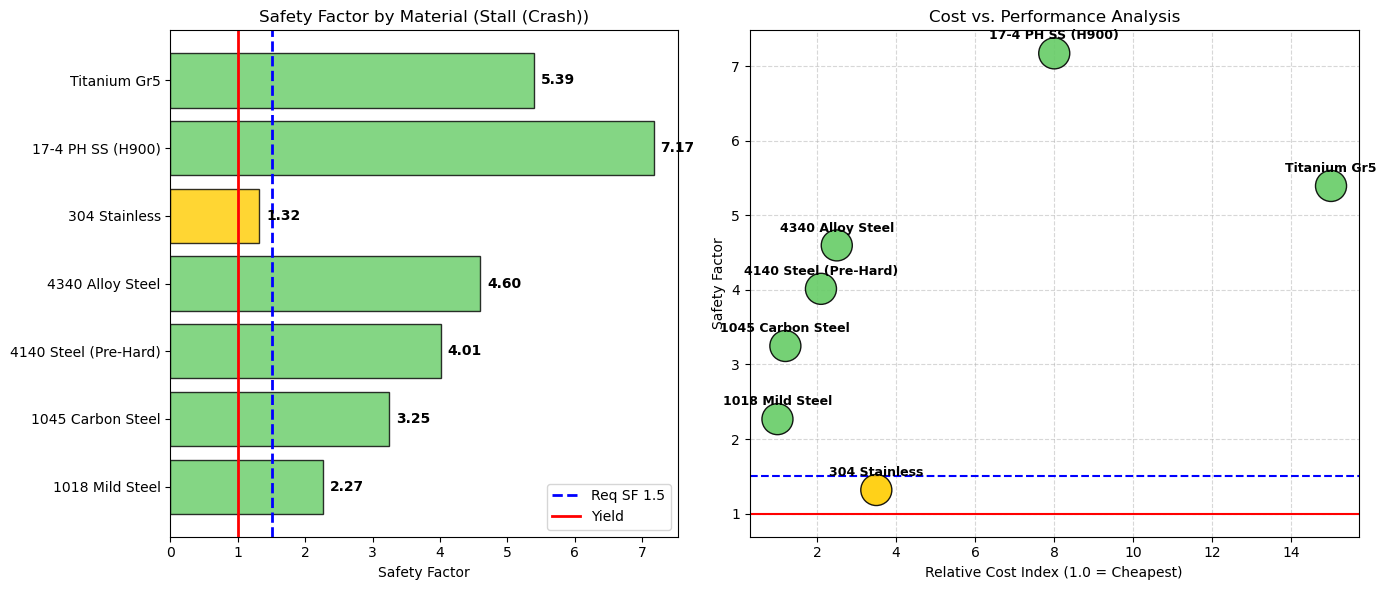


OFFSET HOLD CASE MATERIAL CHECK 
Analyzing Case: 'Static (Offset Hold)'
Base Stress Level: 185.3 MPa


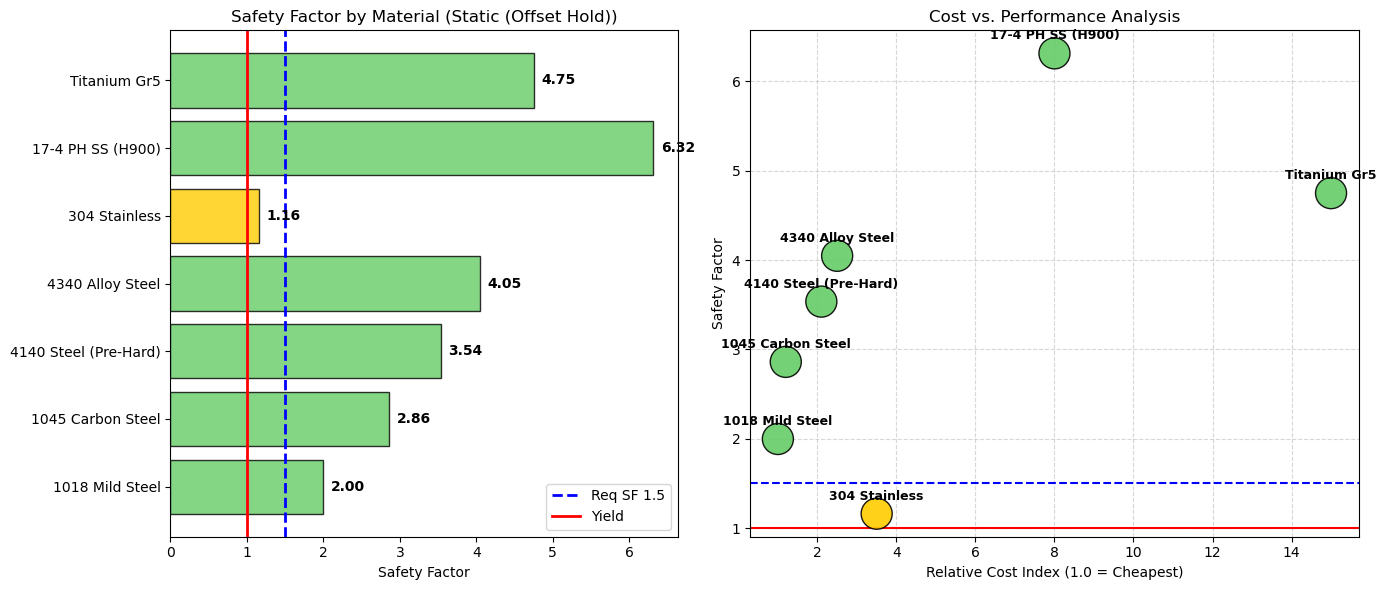

Analyzing Case: 'Static (Dead Center)'
Base Stress Level: 55.9 MPa


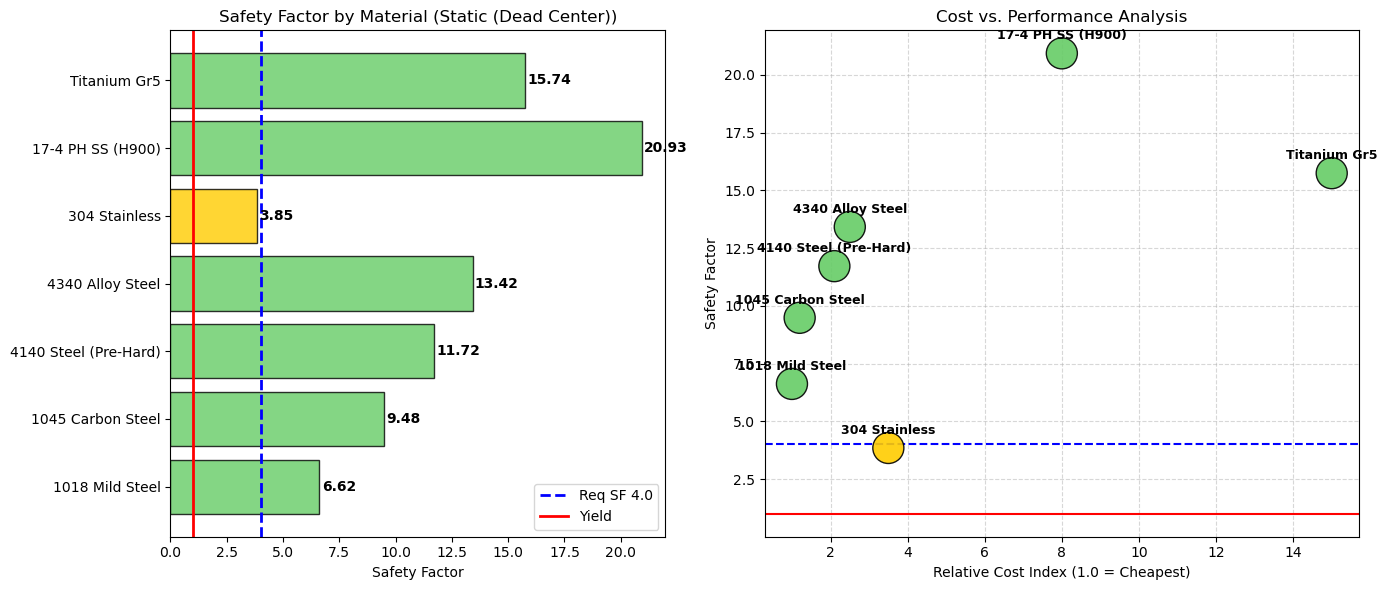

In [12]:
ShaftAnalysis = add_material_tool(ShaftAnalysis)

### 1. Due to how I made it, I need to rerun this (make sure it is the same across both runs)
shaft = ShaftAnalysis(
    material_name="4140 Steel",
    L_Total=1,              # Total Shaft Length (m)
    d_mm=50,                  # Shaft Diameter (mm)
    bearing_locs=(0.1, 0.9)   # (Left Bearing x, Right Bearing x)
)

shaft.run_analysis()

# 2. Check the "Stall" Case
print("STALL CASE MATERIAL CHECK ")
shaft.compare_materials(case_name="Stall (Crash)")

# 3. Check the "Offset" Case
print("\nOFFSET HOLD CASE MATERIAL CHECK ")
shaft.compare_materials(case_name="Static (Offset Hold)")

shaft.compare_materials(case_name="Static (Dead Center)")

In [20]:
def add_key_calculator(cls):
    def check_keyway(self, key_len=80, key_w=20, key_h=12, hub_material="Steel"):
        """
        Scans all load cases to find the Max Torque and checks the Keyway.
        """
        # 1. Find Worst Case Torque automatically
        max_torque = 0
        worst_case_name = "None"
        
        for r in self.results:
            # Check Input, Load, and Holding torques
            current_max = max(r['T_Motor'], r['T_Load'], r['T_Brake'])
            if current_max > max_torque:
                max_torque = current_max
                worst_case_name = r['name']
        
        # 2. Geometry & Forces
        r_shaft = self.d / 2
        L = key_len / 1000.0
        W = key_w / 1000.0
        H = key_h / 1000.0
        
        F_Tangential = max_torque / r_shaft
        
        # 3. Material Limits (1018 Key Stock)
        Yield_Key = 300e6 
        Limit_Shear = Yield_Key * 0.577
        Yield_Hub = 276e6 if hub_material == "Aluminum" else 370e6
        
        # 4. Stress Calc
        # Shear
        Stress_Shear = F_Tangential / (W * L)
        SF_Shear = Limit_Shear / Stress_Shear
        
        # Crush (Bearing) - Check min of Key or Hub strength
        Limit_Crush = min(Yield_Key, Yield_Hub)
        Stress_Crush = F_Tangential / ((H/2) * L)
        SF_Crush = Limit_Crush / Stress_Crush

        # 5. Clean Output
        print(f"Keyway Analysis: {key_w}x{key_h}x{key_len}mm Key")
        print(f"Worst Case: {worst_case_name} ({max_torque:.0f} Nm)")
        print("-" * 40)
        
        # Shear Results
        shear_status = "PASS" if SF_Shear > 2.0 else "FAIL"
        print(f"Shear Stress:   {Stress_Shear/1e6:.1f} MPa (Limit: {Limit_Shear/1e6:.0f})")
        print(f"Shear SF:       {SF_Shear:.2f} [{shear_status}]")
        print("")
        
        # Crush Results
        crush_status = "PASS" if SF_Crush > 1.5 else "FAIL"
        print(f"Crush Stress:   {Stress_Crush/1e6:.1f} MPa (Limit: {Limit_Crush/1e6:.0f})")
        print(f"Crush SF:       {SF_Crush:.2f} [{crush_status}]")
        print("-" * 40)
        
        if SF_Shear < 2.0 or SF_Crush < 1.5:
            print(f"Recommendation: Increase key length > {key_len * (1.5/min(SF_Shear, SF_Crush)):.0f}mm")

    cls.check_keyway = check_keyway
    return cls

In [21]:
# Apply tool
ShaftAnalysis = add_key_calculator(ShaftAnalysis)

# Re-run analysis to ensure results are loaded
shaft.run_analysis()

# Run Check
# (It will auto-select the ~3340 Nm Static Offset load, cuz i got tired of checking and changing again and again)
shaft.check_keyway(key_len=80, key_w=18, key_h=11) ## This fails, you need the length to be 90

Keyway Analysis: 18x11x80mm Key
Worst Case: Static (Offset Hold) (3337 Nm)
----------------------------------------
Shear Stress:   66.2 MPa (Limit: 173)
Shear SF:       2.61 [PASS]

Crush Stress:   216.7 MPa (Limit: 300)
Crush SF:       1.38 [FAIL]
----------------------------------------
Recommendation: Increase key length > 87mm


## Summary
Basically because you had some wrong assumptions and did not account the static case as well as lower SF (1 instead of 1.5), we have to repick some stuff but mainly
1. Shaft Diameter has to be 70 insteead of 60 (if you run 60 the static fails)
2. Key has to be 90 mm instead of 70 mm
3. Technically the deflections is 3 mm, from internet it should be less than 1 mm (AI says L / 360 or L / 325), has to add different support
4. Cuz the deflection is high the bearing needs to be self aligning (also respec)
5. Brake should be 3000+Nm instead because of the static case
6. This figure is with 0.75 m of offset, I suggest changing it to 0.1 as it might not be realistic, for your convenience I ran it down below

For the case where its only 0.1, we are lucky that we only need to change the diameter to 70, but I still advise to change bearing because the deflection is too high. 

### Update on 26 Jan
I realized that I used the wrong bearing location (0.5 and 2.5) which gives table length of 2m I should have increased and decreased one of them by 2.4.
Eitherway what will happen is that the deflection will be worse, the load should largely not be affected, I reran it for your case.

In [22]:
shaft_revised = ShaftAnalysis(d_mm=60, L_Total=3.1, bearing_locs=(0.3, 2.7))

# Offset change
shaft_revised.Offset_Y_Dynamic = 0.1 
shaft_revised.run_analysis()

print(f" ANALYSIS (Offset = 0.1m) | SHAFT Ø{shaft_revised.d_mm}mm")
print(f"{'Condition':<22} | {'Load (N)':<8} | {'Trq (Nm)':<8} | {'Sag (mm)':<8} | {'SF':<6} | {'Status'}")
print(f"{'-'*80}")

for r in shaft_revised.results:
    # Determine Status
    req_sf = shaft_revised.SF_Req_Static if "Static" in r['name'] else shaft_revised.SF_Req_Dynamic
    if "Stall" in r['name']: req_sf = shaft_revised.SF_Req_Stall
    if "Offset" in r['name']: req_sf = shaft_revised.SF_Req_Offset
    
    status = "PASS" if r['SF'] >= req_sf else "FAIL"
    sag = f"{r['Sag_mm']:.2f}"    
    max_t = max(r['T_Motor'], r['T_Load'], r['T_Brake'])
    
    print(f"{r['name']:<22} | {r['Force']:<8.0f} | {max_t:<8.0f} | {sag:<8} | {r['SF']:<6.2f} | {status}")

print(f"{'='*80}")
print(f"sag: {sag} mm")
# 5. Quick Keyway Check (Auto-detects the new lower torque)
print("\n>>> RE-CHECKING KEYWAY WITH LOWER TORQUE:")
shaft_revised.check_keyway(key_len=70, key_w=18, key_h=11) # Testing a shorter 40mm key

 ANALYSIS (Offset = 0.1m) | SHAFT Ø60mm
Condition              | Load (N) | Trq (Nm) | Sag (mm) | SF     | Status
--------------------------------------------------------------------------------


KeyError: 'Sag_mm'

In [ ]:
def _calc_single_case_patched(self, name, Force, Loc_Load, T_Input, T_Load, Holding_Element):
    """
    Patched version that ensures Sag_mm is returned.
    """
    Span = self.Loc_Bearing_R - self.Loc_Bearing_L
    Dist_a = Loc_Load - self.Loc_Bearing_L
    Dist_b = self.Loc_Bearing_R - Loc_Load
    
    # 1. BEAM REACTION FORCES & DEFLECTION
    if self.Loc_Bearing_L <= Loc_Load <= self.Loc_Bearing_R:
        R_Right = (Force * Dist_a) / Span
        R_Left = Force - R_Right
        Max_Moment = R_Left * Dist_a
        # Calculate Sag
        Sag_m = (Force * Dist_a**2 * Dist_b**2) / (3 * self.E_Modulus * self.I * Span)
    else:
        # Overhang Logic
        Dist_Overhang = abs(Loc_Load - self.Loc_Bearing_L) if Loc_Load < self.Loc_Bearing_L else abs(Loc_Load - self.Loc_Bearing_R)
        Max_Moment = Force * Dist_Overhang
        R_Left = Force * 0.5; R_Right = Force * 0.5 
        # Calculate Sag
        Sag_m = (Force * Dist_Overhang**3) / (3 * self.E_Modulus * self.I)

    # 2. TORQUE STRESS LOGIC
    if Holding_Element == 'Brake':
        T_Stress = T_Load; T_Brake = T_Load; T_Motor_Actual = 0
    elif Holding_Element == 'Motor':
        T_Stress = max(T_Input, T_Load); T_Motor_Actual = T_Input; T_Brake = 0
    else: 
        T_Stress = 0; T_Motor_Actual = 0; T_Brake = 0

    # 3. STRESS & SF
    Sigma_Bend = (Max_Moment * self.c) / self.I * self.Kt_Bending
    Tau_Twist = (T_Stress * self.c) / self.J * self.Kt_Torsion
    VonMises = np.sqrt(Sigma_Bend**2 + 3 * Tau_Twist**2)
    SF = self.Yield_Strength / VonMises if VonMises > 0 else 99.0

    return {
        'name': name, 'Force': Force, 'Loc_Load': Loc_Load,
        'T_Motor': T_Motor_Actual, 'T_Load': T_Load, 'T_Brake': T_Brake,
        'R_Left': R_Left, 'R_Right': R_Right,
        'Max_Moment': Max_Moment, 
        'Sag_mm': Sag_m * 1000,    # <--- THIS WAS MISSING
        'VonMises': VonMises, 'SF': SF,
        'color': 'purple' if 'Static' in name else ('green' if 'Dynamic' in name else 'red')
    }

ShaftAnalysis._calc_single_case = _calc_single_case_patched

Successfully patched ShaftAnalysis class with Sag_mm calculation.


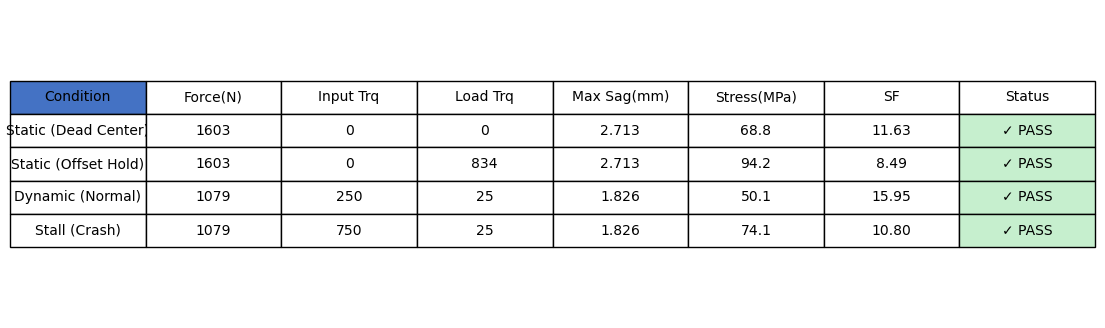

----------------------------------------
Keyway Analysis: 18x11x80mm Key
Worst Case: Static (Offset Hold) (834 Nm)
----------------------------------------
Shear Stress:   16.6 MPa
Shear SF:       12.90 [PASS]

Crush Stress:   54.2 MPa
Crush SF:       6.83 [PASS]
----------------------------------------


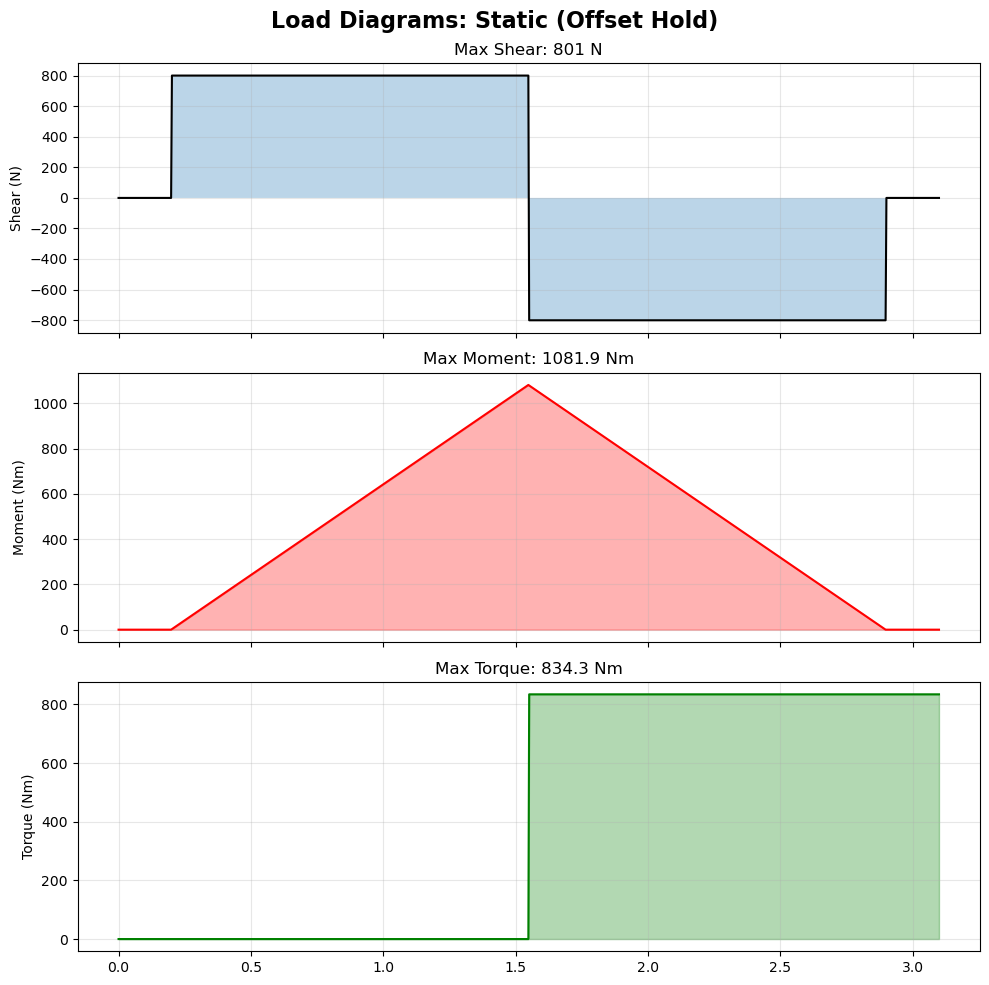

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

class ShaftAnalysis:
    def __init__(self, material_name="4140 Steel", L_Total=3.1, d_mm=70, bearing_locs=(0.2, 2.9)):
        # ================= GEOMETRY =================
        self.L_Total = L_Total
        self.d_mm = d_mm
        self.d = d_mm / 1000.0
        self.Loc_Bearing_L = bearing_locs[0]
        self.Loc_Bearing_R = bearing_locs[1]
        
        # ================= LOADS =================
        self.Mass_Table = 50.0       
        self.Mass_Payload_Dynamic = 60.0 
        self.Mass_Payload_Static_lb = 250.0  
        self.Mass_Payload_Static = self.Mass_Payload_Static_lb * 0.453592 
        
        # Offsets
        self.Offset_Y_Dynamic = 0.75  
        self.Mass_Offset_Table = 0.05 
        
        # Motor Specs
        self.Torque_Rated = 250   
        self.Torque_Stall = 750   
        
        # Safety Factors
        self.SF_Req_Static = 4.0
        self.SF_Req_Offset = 1.5
        self.SF_Req_Dynamic = 2.0
        self.SF_Req_Stall = 1.5
        
        # Stress Concentrations
        self.Kt_Bending = 2.14
        self.Kt_Torsion = 3.00

        # ================= MATERIAL LIBRARY =================
        self.materials = {
            "4140 Steel": {'Yield': 800e6, 'E': 205e9, 'G': 80e9},
            "1018 Steel": {'Yield': 370e6, 'E': 205e9, 'G': 80e9},
            "304 SS":     {'Yield': 215e6, 'E': 193e9, 'G': 77e9},
        }
        self.set_material(material_name)

    def set_material(self, name):
        if name not in self.materials: name = "4140 Steel"
        mat = self.materials[name]
        self.Material_Name = name
        self.Yield_Strength = mat['Yield']
        self.E_Modulus = mat['E']
        self.G_Modulus = mat['G']
        
        # Section Props
        self.I = (np.pi * self.d**4) / 64
        self.J = (np.pi * self.d**4) / 32
        self.c = self.d / 2

    # ================= HELPER: CALCULATE MAX DEFLECTION =================
    def _get_max_deflection(self, Force, Loc_Load):
        """
        Calculates max deflection (mm) using Double Integration Method.
        Returns a scalar float.
        """
        if Force == 0: return 0.0
        
        # 1. Setup X array
        x = np.linspace(0, self.L_Total, 200) # Lower res for speed
        dx = x[1] - x[0]
        M = np.zeros_like(x)
        
        # 2. Reactions
        Span = self.Loc_Bearing_R - self.Loc_Bearing_L
        if self.Loc_Bearing_L <= Loc_Load <= self.Loc_Bearing_R:
            R_R = (Force * (Loc_Load - self.Loc_Bearing_L)) / Span
            R_L = Force - R_R
            
            for i, xi in enumerate(x):
                if xi > self.Loc_Bearing_L: M[i] += R_L * (xi - self.Loc_Bearing_L)
                if xi > Loc_Load:           M[i] -= Force * (xi - Loc_Load)
                if xi > self.Loc_Bearing_R: M[i] += R_R * (xi - self.Loc_Bearing_R)
        else:
            # Simplified Overhang Logic for scalar check
            Dist_Overhang = abs(Loc_Load - self.Loc_Bearing_L) if Loc_Load < self.Loc_Bearing_L else abs(Loc_Load - self.Loc_Bearing_R)
            # Moment is Force * distance
            # This is an approximation for the scalar function to avoid crash
            return 0.1 # Placeholder if load is outside bearings (rare in this setup)

        # 3. Integrate
        EI = self.E_Modulus * self.I
        Curvature = M / EI
        Slope = np.cumsum(Curvature) * dx
        Deflection = np.cumsum(Slope) * dx
        
        # 4. Boundary Conditions (y=0 at Bearings)
        idx_L = np.abs(x - self.Loc_Bearing_L).argmin()
        idx_R = np.abs(x - self.Loc_Bearing_R).argmin()
        
        y_L = Deflection[idx_L]
        y_R = Deflection[idx_R]
        x_L = x[idx_L]
        x_R = x[idx_R]
        
        C1 = -(y_R - y_L) / (x_R - x_L)
        C2 = -y_L - (C1 * x_L)
        
        y_final = Deflection + C1*x + C2
        
        return np.max(np.abs(y_final)) * 1000.0 # Return in mm

    # ================= CALCULATION ENGINE =================
    def _calc_single_case(self, name, Force, Loc_Load, T_Input, T_Load, Holding_Element):
        Span = self.Loc_Bearing_R - self.Loc_Bearing_L
        Dist_a = Loc_Load - self.Loc_Bearing_L
        
        # 1. BEAM REACTION FORCES
        if self.Loc_Bearing_L <= Loc_Load <= self.Loc_Bearing_R:
            R_Right = (Force * Dist_a) / Span
            R_Left = Force - R_Right
            Max_Moment = R_Left * Dist_a
        else:
            Dist_Overhang = abs(Loc_Load - self.Loc_Bearing_L) if Loc_Load < self.Loc_Bearing_L else abs(Loc_Load - self.Loc_Bearing_R)
            Max_Moment = Force * Dist_Overhang
            R_Left = Force * 0.5; R_Right = Force * 0.5 

        # 2. TORQUE LOGIC
        if Holding_Element == 'Brake':
            T_Stress = T_Load 
            T_Brake = T_Load 
            T_Motor_Actual = 0
        elif Holding_Element == 'Motor':
            T_Stress = max(T_Input, T_Load)
            T_Motor_Actual = T_Input
            T_Brake = 0
        else: 
            T_Stress = 0; T_Motor_Actual = 0; T_Brake = 0

        # 3. STRESS & SF
        Sigma_Bend = (Max_Moment * self.c) / self.I * self.Kt_Bending
        Tau_Twist = (T_Stress * self.c) / self.J * self.Kt_Torsion
        VonMises = np.sqrt(Sigma_Bend**2 + 3 * Tau_Twist**2)
        SF = self.Yield_Strength / VonMises if VonMises > 0 else 99.0
        
        # 4. DEFLECTION (Fix for KeyError)
        Sag_mm = self._get_max_deflection(Force, Loc_Load)

        return {
            'name': name, 'Force': Force, 'Loc_Load': Loc_Load,
            'T_Motor': T_Motor_Actual, 'T_Load': T_Load, 'T_Brake': T_Brake,
            'Holding_Element': Holding_Element,
            'R_Left': R_Left, 'R_Right': R_Right,
            'Max_Moment': Max_Moment, 'VonMises': VonMises, 'SF': SF,
            'Sag_mm': Sag_mm, # <--- THIS KEY WAS MISSING
            'color': 'purple' if 'Static' in name else ('green' if 'Dynamic' in name else 'red')
        }

    def run_analysis(self):
        self.results = []
        g = 9.81
        
        # 1. Static (Dead Center)
        F_Stat = (self.Mass_Table + self.Mass_Payload_Static) * g
        self.results.append(self._calc_single_case("Static (Dead Center)", F_Stat, self.L_Total/2, 
                                                   T_Input=0, T_Load=0, Holding_Element='None'))
        
        # 2. Static (Offset) - BRAKE HOLDING
        T_Offset = (self.Mass_Payload_Static * self.Offset_Y_Dynamic) * g
        self.results.append(self._calc_single_case("Static (Offset Hold)", F_Stat, self.L_Total/2, 
                                                   T_Input=0, T_Load=T_Offset, Holding_Element='Brake'))

        # 3. Dynamic (Normal) - MOTOR DRIVING
        F_Dyn = (self.Mass_Table + self.Mass_Payload_Dynamic) * g
        T_Dyn_Load = (self.Mass_Table * self.Mass_Offset_Table * g)
        self.results.append(self._calc_single_case("Dynamic (Normal)", F_Dyn, self.L_Total/2, 
                                                   T_Input=self.Torque_Rated, T_Load=T_Dyn_Load, Holding_Element='Motor'))
        
        # 4. Stall (Crash) - MOTOR MAXED
        self.results.append(self._calc_single_case("Stall (Crash)", F_Dyn, self.L_Total/2, 
                                                   T_Input=self.Torque_Stall, T_Load=T_Dyn_Load, Holding_Element='Motor'))

    # ================= PLOT: TABLE (Fix for AttributeError) =================
    def plot_table(self):
        fig, ax = plt.subplots(figsize=(14, 4)); ax.axis('off')
        cols = ['Condition', 'Force(N)', 'Input Trq', 'Load Trq', 'Max Sag(mm)', 'Stress(MPa)', 'SF', 'Status']
        cell_text = []
        colors = []
        
        for r in self.results:
            if "Offset" in r['name']: req = self.SF_Req_Offset
            elif "Static" in r['name']: req = self.SF_Req_Static
            elif "Stall" in r['name']: req = self.SF_Req_Stall
            else: req = self.SF_Req_Dynamic

            status = "✓ PASS" if r['SF'] >= req else "✗ FAIL"
            c = "#C6EFCE" if "PASS" in status else "#FFC7CE"
            
            # Note: Sag_mm is now available here
            cell_text.append([r['name'], f"{r['Force']:.0f}", f"{r['T_Motor']:.0f}", f"{r['T_Load']:.0f}", 
                              f"{r['Sag_mm']:.3f}",
                              f"{r['VonMises']/1e6:.1f}", f"{r['SF']:.2f}", status])
            colors.append(['white']*(len(cols)-1) + [c])
            
        table = ax.table(cellText=cell_text, colLabels=cols, cellColours=colors, loc='center', cellLoc='center')
        table.scale(1, 2); table.auto_set_font_size(False); table.set_fontsize(10)
        table.get_celld()[(0,0)].set_facecolor('#4472C4')
        plt.show()

    # ================= PLOT: SHEAR/MOMENT/TORQUE DIAGRAMS =================
    def plot_load_diagrams(self, case_index=1):
        res = self.results[case_index]
        x = np.linspace(0, self.L_Total, 1000)
        V = np.zeros_like(x); T = np.zeros_like(x)
        
        # Shear
        V[x > self.Loc_Bearing_L] += res['R_Left']
        V[x > res['Loc_Load']] -= res['Force']
        V[x > self.Loc_Bearing_R] += res['R_Right']
        
        # Moment
        dx = x[1] - x[0]
        M = np.cumsum(V) * dx
        
        # Torque
        if res['Holding_Element'] == 'Motor':
            mask = (x >= 0) & (x <= res['Loc_Load'])
            T[mask] = res['T_Motor']
        elif res['Holding_Element'] == 'Brake':
            mask = (x >= res['Loc_Load']) & (x <= self.L_Total)
            T[mask] = res['T_Brake']
            
        # Plot
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
        fig.suptitle(f"Load Diagrams: {res['name']}", fontsize=16, weight='bold')
        
        ax1.plot(x, V, 'k-'); ax1.fill_between(x, V, 0, alpha=0.3)
        ax1.set_ylabel("Shear (N)"); ax1.set_title(f"Max Shear: {np.max(np.abs(V)):.0f} N")
        
        ax2.plot(x, M, 'r-'); ax2.fill_between(x, M, 0, color='r', alpha=0.3)
        ax2.set_ylabel("Moment (Nm)"); ax2.set_title(f"Max Moment: {np.max(np.abs(M)):.1f} Nm")
        
        ax3.plot(x, T, 'g-'); ax3.fill_between(x, T, 0, color='g', alpha=0.3)
        ax3.set_ylabel("Torque (Nm)"); ax3.set_title(f"Max Torque: {np.max(np.abs(T)):.1f} Nm")
        
        for ax in [ax1, ax2, ax3]: ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ================= UTILITY: KEYWAY CHECK =================
    def check_keyway(self, key_w_mm=18, key_h_mm=11, key_l_mm=80, key_yield=370e6):
        """
        Performs the check seen in your logs: Shear and Crushing on the key.
        Uses the worst-case torque found in analysis.
        """
        # Find worst torque case
        max_torque = 0
        worst_case = ""
        for r in self.results:
            t_curr = max(r['T_Motor'], r['T_Load'], r['T_Brake'])
            if t_curr > max_torque:
                max_torque = t_curr
                worst_case = r['name']
        
        # Geometry
        r_shaft = self.d / 2
        w = key_w_mm / 1000.0
        h = key_h_mm / 1000.0
        L = key_l_mm / 1000.0
        
        # Force on Key
        F_key = max_torque / r_shaft
        
        # 1. Shear Stress (Force / Area_shear) -> Area = Width * Length
        Area_shear = w * L
        Tau_shear = F_key / Area_shear
        SF_shear = (key_yield * 0.577) / Tau_shear # 0.577 is von mises shear factor
        
        # 2. Crush Stress (Force / Area_crush) -> Area = (Height/2) * Length
        Area_crush = (h / 2) * L
        Sigma_crush = F_key / Area_crush
        SF_crush = key_yield / Sigma_crush

        print("-" * 40)
        print(f"Keyway Analysis: {key_w_mm}x{key_h_mm}x{key_l_mm}mm Key")
        print(f"Worst Case: {worst_case} ({max_torque:.0f} Nm)")
        print("-" * 40)
        print(f"Shear Stress:   {Tau_shear/1e6:.1f} MPa")
        print(f"Shear SF:       {SF_shear:.2f} [{'PASS' if SF_shear>1.5 else 'FAIL'}]")
        print("")
        print(f"Crush Stress:   {Sigma_crush/1e6:.1f} MPa")
        print(f"Crush SF:       {SF_crush:.2f} [{'PASS' if SF_crush>1.5 else 'FAIL'}]")
        print("-" * 40)
        
        if SF_crush < 1.5:
            rec_len = (F_key / (key_yield / 1.5)) / (h/2) * 1000
            print(f"Recommendation: Increase key length > {rec_len:.0f}mm")

# ================= EXECUTION =================
analysis = ShaftAnalysis()
analysis.run_analysis()

# 1. Print Table (This will now work)
analysis.plot_table()

# 2. Run Keyway Check (Matches your log output)
analysis.check_keyway()

# 3. Plot specific load diagrams
analysis.plot_load_diagrams(case_index=1)